# Home Credit Default Risk

## Introduction

### Load the data efficiently

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, ttest_ind
# automated feature engineering
import featuretools as ft

# Filter out pandas warnings
import warnings 
warnings.filterwarnings('ignore')

start = "\033[1m"  # Bold text
end = "\033[0;0m"  # Reset text
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

In [2]:



# https://www.kaggle.com/questions-and-answers/118932
# Max rows and columns of pandas dataframe
pd.options.display.max_rows, pd.options.display.max_columns

# https://thispointer.com/python-pandas-how-to-display-full-dataframe-i-e-print-all-rows-columns-without-truncation/
# Print all the contents of a pandas dataframe
pd.set_option(
    "display.max_rows", None
)  # Print unlimited number of rows by setting to None, default is 10
pd.set_option(
    "display.max_columns", None
)  # Do not truncate columns to display all of them by setting to None
pd.set_option(
    "display.width", None
)  # Auto-detect the width of dataframe to display all columns in single line by setting to None
pd.set_option(
    "display.max_colwidth", None
)  # Auto detect the max size of column and print contents of that column without truncation

(60, 20)

In [3]:
def reduce_mem_usage(df):
    """iterate through all the columns of a dataframe and modify the data type
    to reduce memory usage.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print("Memory usage of dataframe is {:.2f} MB".format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if (
                    c_min > np.finfo(np.float16).min
                    and c_max < np.finfo(np.float16).max
                ):
                    df[col] = df[col].astype(np.float16)
                elif (
                    c_min > np.finfo(np.float32).min
                    and c_max < np.finfo(np.float32).max
                ):
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype("category")

    end_mem = df.memory_usage().sum() / 1024**2
    print("Memory usage after optimization is: {:.2f} MB".format(end_mem))
    print("Decreased by {:.1f}%".format(100 * (start_mem - end_mem) / start_mem))

    return df


def import_data(file):
    """create a dataframe and optimize its memory usage"""
    df = pd.read_csv(file, parse_dates=True, keep_date_col=True)
    df = reduce_mem_usage(df)
    return df

In [4]:
print("-" * 80)
print("train")
train = import_data("data/application_train.csv")

print("-" * 80)
print("test")
test = import_data("data/application_test.csv")

print("-" * 80)
print("bureau_balance")
bureau_balance = import_data("data/bureau_balance.csv")

print("-" * 80)
print("bureau")
bureau = import_data("data/bureau.csv")

print("-" * 80)
print("credit_card_balance")
credit_card = import_data("data/credit_card_balance.csv")

print("-" * 80)
print("installments_payments")
installments = import_data("data/installments_payments.csv")

print("-" * 80)
print("pos_cash_balance")
pos_cash = import_data("data/POS_CASH_balance.csv")

print("-" * 80)
print("previous_application")
previous_app = import_data("data/previous_application.csv")

--------------------------------------------------------------------------------
train
Memory usage of dataframe is 286.23 MB
Memory usage after optimization is: 59.54 MB
Decreased by 79.2%
--------------------------------------------------------------------------------
test
Memory usage of dataframe is 45.00 MB
Memory usage after optimization is: 9.40 MB
Decreased by 79.1%
--------------------------------------------------------------------------------
bureau_balance
Memory usage of dataframe is 624.85 MB
Memory usage after optimization is: 156.21 MB
Decreased by 75.0%
--------------------------------------------------------------------------------
bureau
Memory usage of dataframe is 222.62 MB
Memory usage after optimization is: 78.57 MB
Decreased by 64.7%
--------------------------------------------------------------------------------
credit_card_balance
Memory usage of dataframe is 673.88 MB
Memory usage after optimization is: 263.69 MB
Decreased by 60.9%
---------------------------

### Data model

There are 7 different sources of data:

- **train/application_test**: the main training and testing data with information about each loan application at Home Credit. Every loan has its own row and is identified by the feature SK_ID_CURR. The training application data comes with the TARGET indicating 0: the loan was repaid or 1: the loan was not repaid.

- **bureau**: data concerning client's previous credits from other financial institutions. Each previous credit has its own row in bureau, but one loan in the application data can have multiple previous credits.

- **bureau_balance**: monthly data about the previous credits in bureau. Each row is one month of a previous credit, and a single previous credit can have multiple rows, one for each month of the credit length.

- **previous_application**: previous applications for loans at Home Credit of clients who have loans in the application data. Each current loan in the application data can have multiple previous loans. Each previous application has one row and is identified by the feature SK_ID_PREV.

- **POS_CASH_BALANCE**: monthly data about previous point of sale or cash loans clients have had with Home Credit. Each row is one month of a previous point of sale or cash loan, and a single previous loan can have many rows.

- **credit_card_balance**: monthly data about previous credit cards clients have had with Home Credit. Each row is one month of a credit card balance, and a single credit card can have many rows.

- **installments_payment**: payment history for previous loans at Home Credit. There is one row for every made payment and one row for every missed payment.


#### Schema visualization
<img src="data/home_credit.png" alt="Alternative text" />

#### Column Description

In [5]:
desc = pd.read_csv("data/HomeCredit_columns_description.csv", encoding="latin")
desc.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [6]:
train["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

### Data glimpse

In [7]:
print("train -  rows:", train.shape[0], " columns:", train.shape[1])
print("application_test -  rows:", test.shape[0], " columns:", test.shape[1])
print("bureau -  rows:", bureau.shape[0], " columns:", bureau.shape[1])
print(
    "bureau_balance -  rows:",
    bureau_balance.shape[0],
    " columns:",
    bureau_balance.shape[1],
)
print(
    "credit_card_balance -  rows:",
    credit_card.shape[0],
    " columns:",
    credit_card.shape[1],
)
print(
    "installments_payments -  rows:",
    installments.shape[0],
    " columns:",
    installments.shape[1],
)
print(
    "previous_application -  rows:",
    previous_app.shape[0],
    " columns:",
    previous_app.shape[1],
)
print("POS_CASH_balance -  rows:", pos_cash.shape[0], " columns:", pos_cash.shape[1])

train -  rows: 307511  columns: 122
application_test -  rows: 48744  columns: 121
bureau -  rows: 1716428  columns: 17
bureau_balance -  rows: 27299925  columns: 3
credit_card_balance -  rows: 3840312  columns: 23
installments_payments -  rows: 13605401  columns: 8
previous_application -  rows: 1670214  columns: 37
POS_CASH_balance -  rows: 10001358  columns: 8


In [8]:
train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [9]:
train.shape, test.shape
train.shape[0] / (train.shape[0] + test.shape[0]) * 100 # Percentage of train data

((307511, 122), (48744, 121))

86.31766571697239

### Data imbalance

In [10]:
print(start + "1 = client with payment difficulties" + end)
print(start + "0 = all other cases" + end)
train.TARGET.value_counts(normalize=True)

1 = client with payment difficulties
0 = all other cases


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

### Missing values

In [11]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

print(start + "Train Data" + end)
missing_values_table(train).head(5)
print(start + "Test Data" + end)
missing_values_table(test).head(5)
print(start + "Bureau Data" + end)
missing_values_table(bureau).head(5)
print(start + "Bureau Balance Data" + end)
missing_values_table(bureau_balance).head(5)
print(start + "Credit Card Data" + end)
missing_values_table(credit_card).head(5)
print(start + "Installments Data" + end)
missing_values_table(installments).head(5)
print(start + "POS Cash Data" + end)
missing_values_table(pos_cash).head(5)
print(start + "Previous Application Data" + end)
missing_values_table(previous_app).head(5)

Train Data
Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_AVG,214865,69.9
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_AVG,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4


Test Data
Your selected dataframe has 121 columns.
There are 64 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_AVG,33495,68.7
COMMONAREA_MODE,33495,68.7
COMMONAREA_MEDI,33495,68.7
NONLIVINGAPARTMENTS_AVG,33347,68.4
NONLIVINGAPARTMENTS_MODE,33347,68.4


Bureau Data
Your selected dataframe has 17 columns.
There are 7 columns that have missing values.


...

,Missing Values,% of Total Values
DAYS_ENTRY_PAYMENT,2905,0.0
AMT_PAYMENT,2905,0.0


POS Cash Data
Your selected dataframe has 8 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
CNT_INSTALMENT_FUTURE,26087,0.3
CNT_INSTALMENT,26071,0.3


Previous Application Data
Your selected dataframe has 37 columns.
There are 16 columns that have missing values.


,Missing Values,% of Total Values
RATE_INTEREST_PRIVILEGED,1664263,99.6
RATE_INTEREST_PRIMARY,1664263,99.6
AMT_DOWN_PAYMENT,895844,53.6
RATE_DOWN_PAYMENT,895844,53.6
NAME_TYPE_SUITE,820405,49.1


### Variable types

In [12]:
train.dtypes.value_counts()

float16     61
int8        37
float32      4
int32        2
category     2
int16        2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

In [13]:
# sample the first 100 rows of train
train_sample = train.sample(100)
# save to csv
train_sample.to_csv("train_sample.csv", index=False)

In [14]:
def find_statistically_significant_features(data, target_var):
    features = data.columns.drop(target_var)
    significant_features = []

    for feature in features:
        if pd.api.types.is_numeric_dtype(data[feature]):
            # Exclude NaN values for statistical testing
            group1 = data[data[target_var] == 0][feature].dropna()
            group2 = data[data[target_var] == 1][feature].dropna()
            
            if len(group1) > 0 and len(group2) > 0:
                # Use Mann-Whitney U test by default for numeric data
                stat, p = mannwhitneyu(group1, group2)
                if p < 0.05:
                    significant_features.append((feature, 'Numeric', p))
        else:
            # For categorical data, ensure it's encoded or exclude from certain tests
            if data[feature].dtype.name == 'category' or len(data[feature].unique()) <= 20:
                # Create a contingency table
                contingency_table = pd.crosstab(data[feature], data[target_var])
                chi2, p, dof, expected = chi2_contingency(contingency_table)
                if p < 0.05:
                    significant_features.append((feature, 'Categorical', p))
    
    return significant_features


# Find significant features
significant_features = find_statistically_significant_features(train, "TARGET")

# Print significant features and their p-values
significant_features_list = [(feature[0], feature[1]) for feature in significant_features]
significant_features_list

[('NAME_CONTRACT_TYPE', 'Categorical'),
 ('CODE_GENDER', 'Categorical'),
 ('FLAG_OWN_CAR', 'Categorical'),
 ('FLAG_OWN_REALTY', 'Categorical'),
 ('CNT_CHILDREN', 'Numeric'),
 ('AMT_INCOME_TOTAL', 'Numeric'),
 ('AMT_CREDIT', 'Numeric'),
 ('AMT_GOODS_PRICE', 'Numeric'),
 ('NAME_TYPE_SUITE', 'Categorical'),
 ('NAME_INCOME_TYPE', 'Categorical'),
 ('NAME_EDUCATION_TYPE', 'Categorical'),
 ('NAME_FAMILY_STATUS', 'Categorical'),
 ('NAME_HOUSING_TYPE', 'Categorical'),
 ('REGION_POPULATION_RELATIVE', 'Numeric'),
 ('DAYS_BIRTH', 'Numeric'),
 ('DAYS_EMPLOYED', 'Numeric'),
 ('DAYS_REGISTRATION', 'Numeric'),
 ('DAYS_ID_PUBLISH', 'Numeric'),
 ('OWN_CAR_AGE', 'Numeric'),
 ('FLAG_EMP_PHONE', 'Numeric'),
 ('FLAG_WORK_PHONE', 'Numeric'),
 ('FLAG_PHONE', 'Numeric'),
 ('OCCUPATION_TYPE', 'Categorical'),
 ('CNT_FAM_MEMBERS', 'Numeric'),
 ('REGION_RATING_CLIENT', 'Numeric'),
 ('REGION_RATING_CLIENT_W_CITY', 'Numeric'),
 ('WEEKDAY_APPR_PROCESS_START', 'Categorical'),
 ('HOUR_APPR_PROCESS_START', 'Numeric'),
 

In [15]:
significant_features_list[0]

('NAME_CONTRACT_TYPE', 'Categorical')

102/121 features found statistically significant

In [16]:
insights = []

# Generating insights for each significant feature
for feature, feature_type in significant_features_list:
    if feature_type == 'Categorical':
        # For categorical features, calculate the proportion of non-repayment for each category
        proportions = train.groupby(feature)['TARGET'].mean().sort_values()
        # Assuming the first category is the one with lesser issues and the last one with more issues
        least_issue_category = proportions.idxmin()
        most_issue_category = proportions.idxmax()
        insight = f"{most_issue_category} in {feature} are more likely to have repayment issues than {least_issue_category}."
        insights.append(insight)
    else:  # Numeric
        # For numeric features, compare mean values for the target variable
        mean_values = train.groupby('TARGET')[feature].mean()
        if mean_values.loc[1] > mean_values.loc[0]:  # If mean for non-repayment (TARGET=1) is higher
            insight = f"Higher values of {feature} are associated with more repayment issues."
        else:
            insight = f"Lower values of {feature} are associated with more repayment issues."
        insights.append(insight)

insights

['Cash loans in NAME_CONTRACT_TYPE are more likely to have repayment issues than Revolving loans.',
 'M in CODE_GENDER are more likely to have repayment issues than XNA.',
 'N in FLAG_OWN_CAR are more likely to have repayment issues than Y.',
 'N in FLAG_OWN_REALTY are more likely to have repayment issues than Y.',
 'Higher values of CNT_CHILDREN are associated with more repayment issues.',
 'Lower values of AMT_INCOME_TOTAL are associated with more repayment issues.',
 'Lower values of AMT_CREDIT are associated with more repayment issues.',
 'Lower values of AMT_GOODS_PRICE are associated with more repayment issues.',
 'Other_B in NAME_TYPE_SUITE are more likely to have repayment issues than Children.',
 'Maternity leave in NAME_INCOME_TYPE are more likely to have repayment issues than Businessman.',
 'Lower secondary in NAME_EDUCATION_TYPE are more likely to have repayment issues than Academic degree.',
 'Civil marriage in NAME_FAMILY_STATUS are more likely to have repayment issues t

### Data visualization

#### Total Income 

In [17]:
def plot_distribution(feature, color, desc):
    plt.figure(figsize=(10, 6))
    plt.title(f"Distribution of {feature} ({desc})")
    sns.distplot(train[feature].dropna(), color=color, kde=True, bins=100)
    plt.show()


def plot_distribution_comp(var, nrow=2):

    i = 0
    t1 = train.loc[train["TARGET"] != 0]
    t0 = train.loc[train["TARGET"] == 0]

    sns.set_style("whitegrid")
    plt.figure()
    fig, ax = plt.subplots(nrow, 2, figsize=(12, 6 * nrow))

    for feature in var:
        i += 1
        plt.subplot(nrow, 2, i)
        sns.kdeplot(t1[feature], bw=0.5, label="TARGET = 1")
        sns.kdeplot(t0[feature], bw=0.5, label="TARGET = 0")
        plt.ylabel("Density plot", fontsize=12)
        plt.xlabel(feature, fontsize=12)
        locs, labels = plt.xticks()
        plt.tick_params(axis="both", which="major", labelsize=12)
    plt.show()

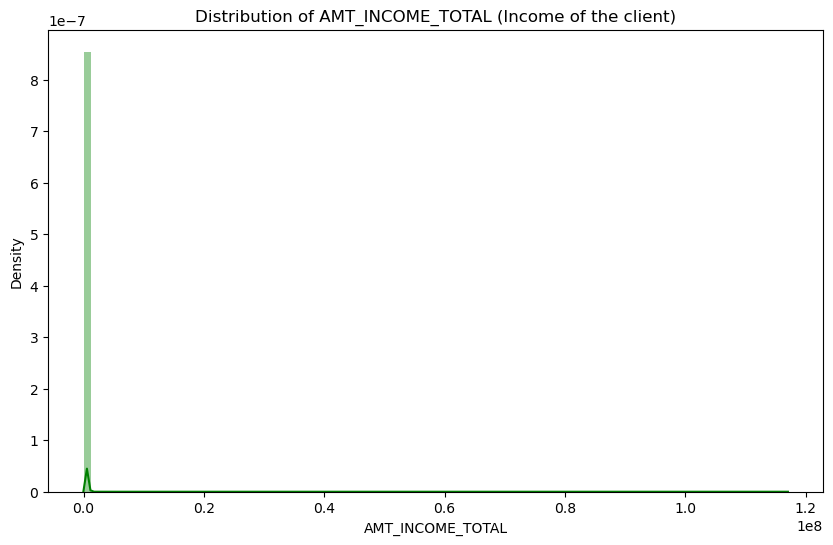

In [18]:
plot_distribution('AMT_INCOME_TOTAL','green', 'Income of the client')

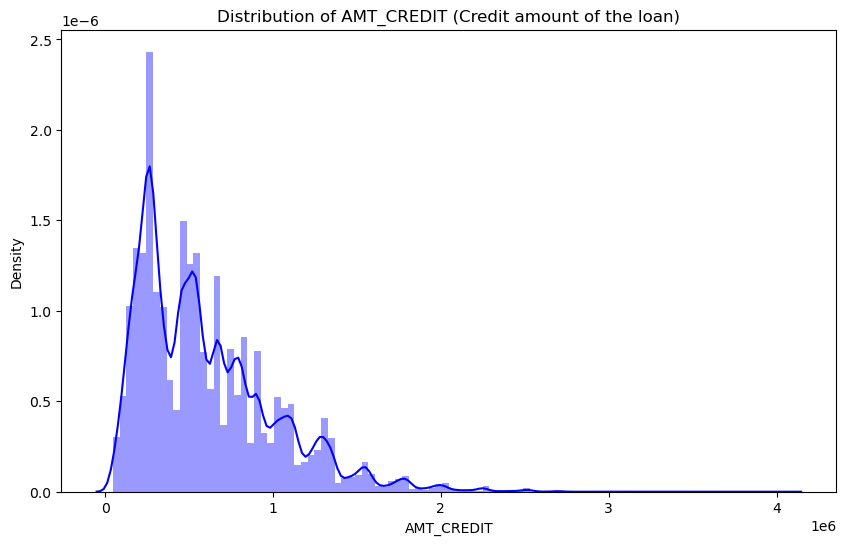

In [19]:
plot_distribution('AMT_CREDIT','blue', 'Credit amount of the loan')

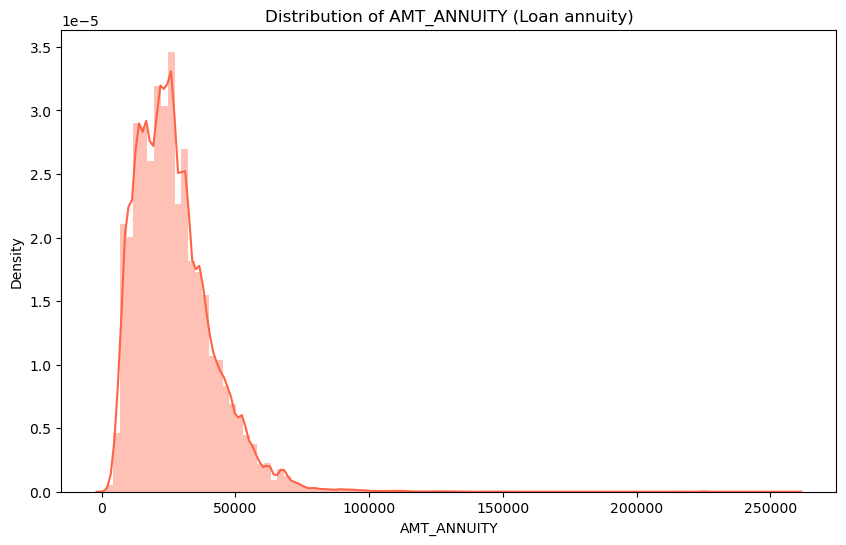

In [20]:
plot_distribution('AMT_ANNUITY','tomato', 'Loan annuity')

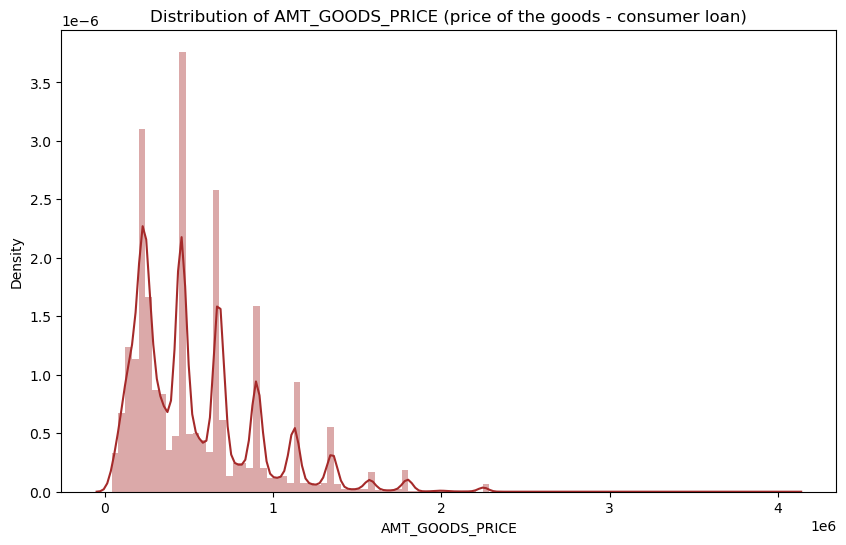

In [21]:
plot_distribution('AMT_GOODS_PRICE','brown', 'price of the goods - consumer loan')

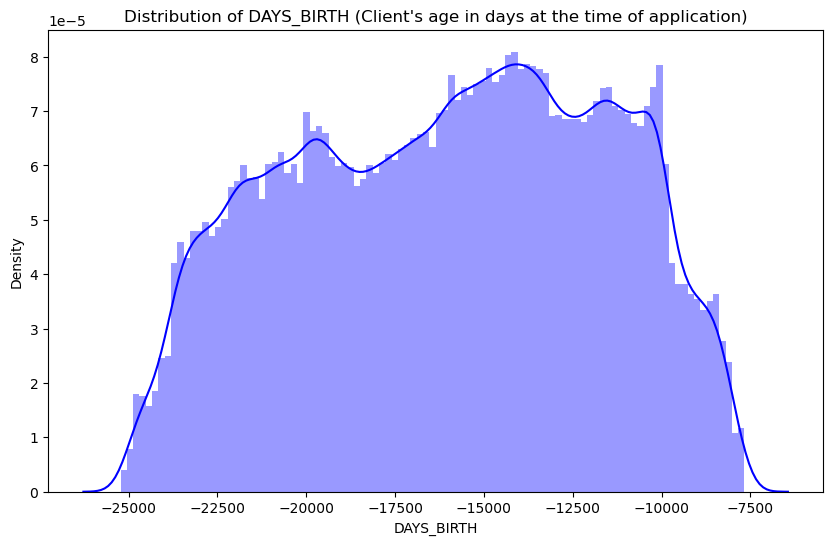

In [22]:
plot_distribution('DAYS_BIRTH','blue', 'Client\'s age in days at the time of application')

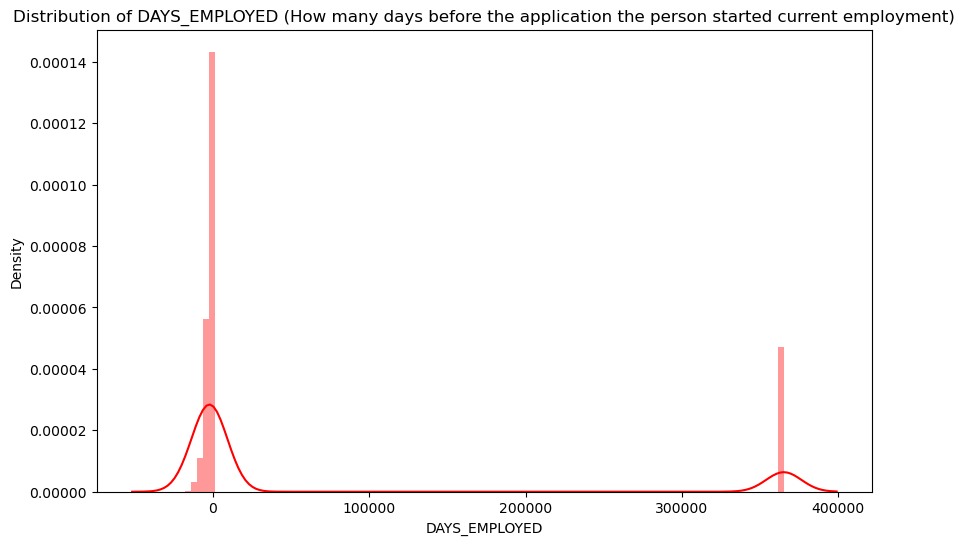

In [23]:
plot_distribution('DAYS_EMPLOYED','red', 'How many days before the application the person started current employment')

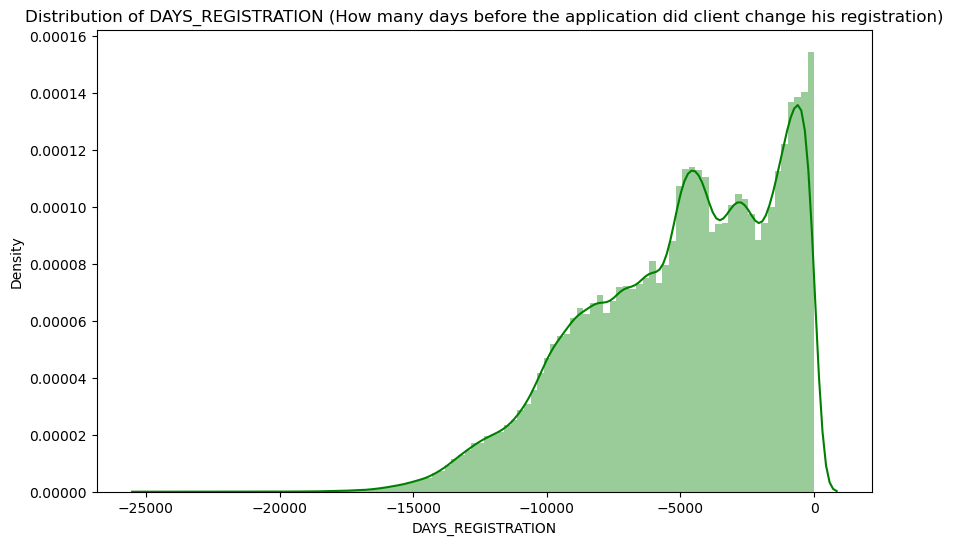

In [24]:
plot_distribution('DAYS_REGISTRATION','green', 'How many days before the application did client change his registration')


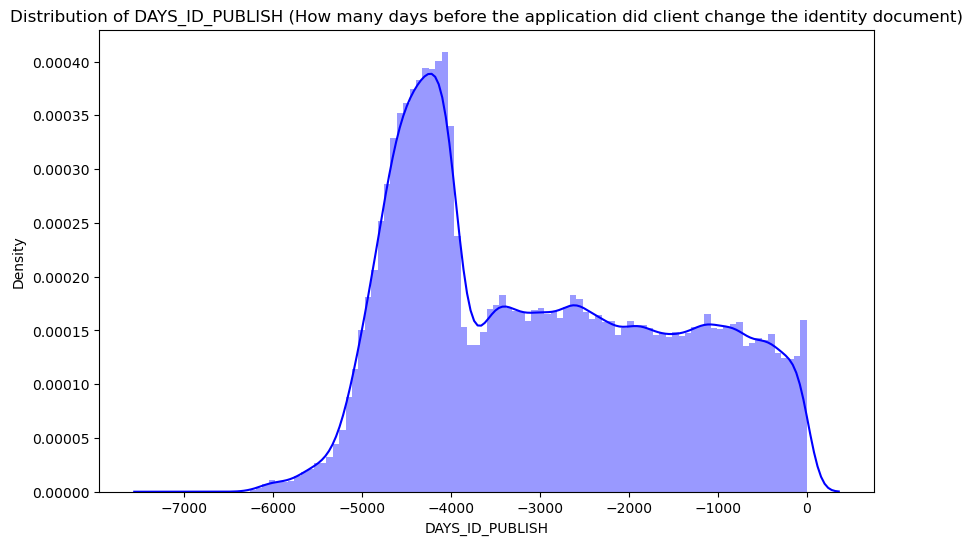

In [25]:
plot_distribution('DAYS_ID_PUBLISH','blue', 'How many days before the application did client change the identity document')

### Comparison plots

<Figure size 640x480 with 0 Axes>

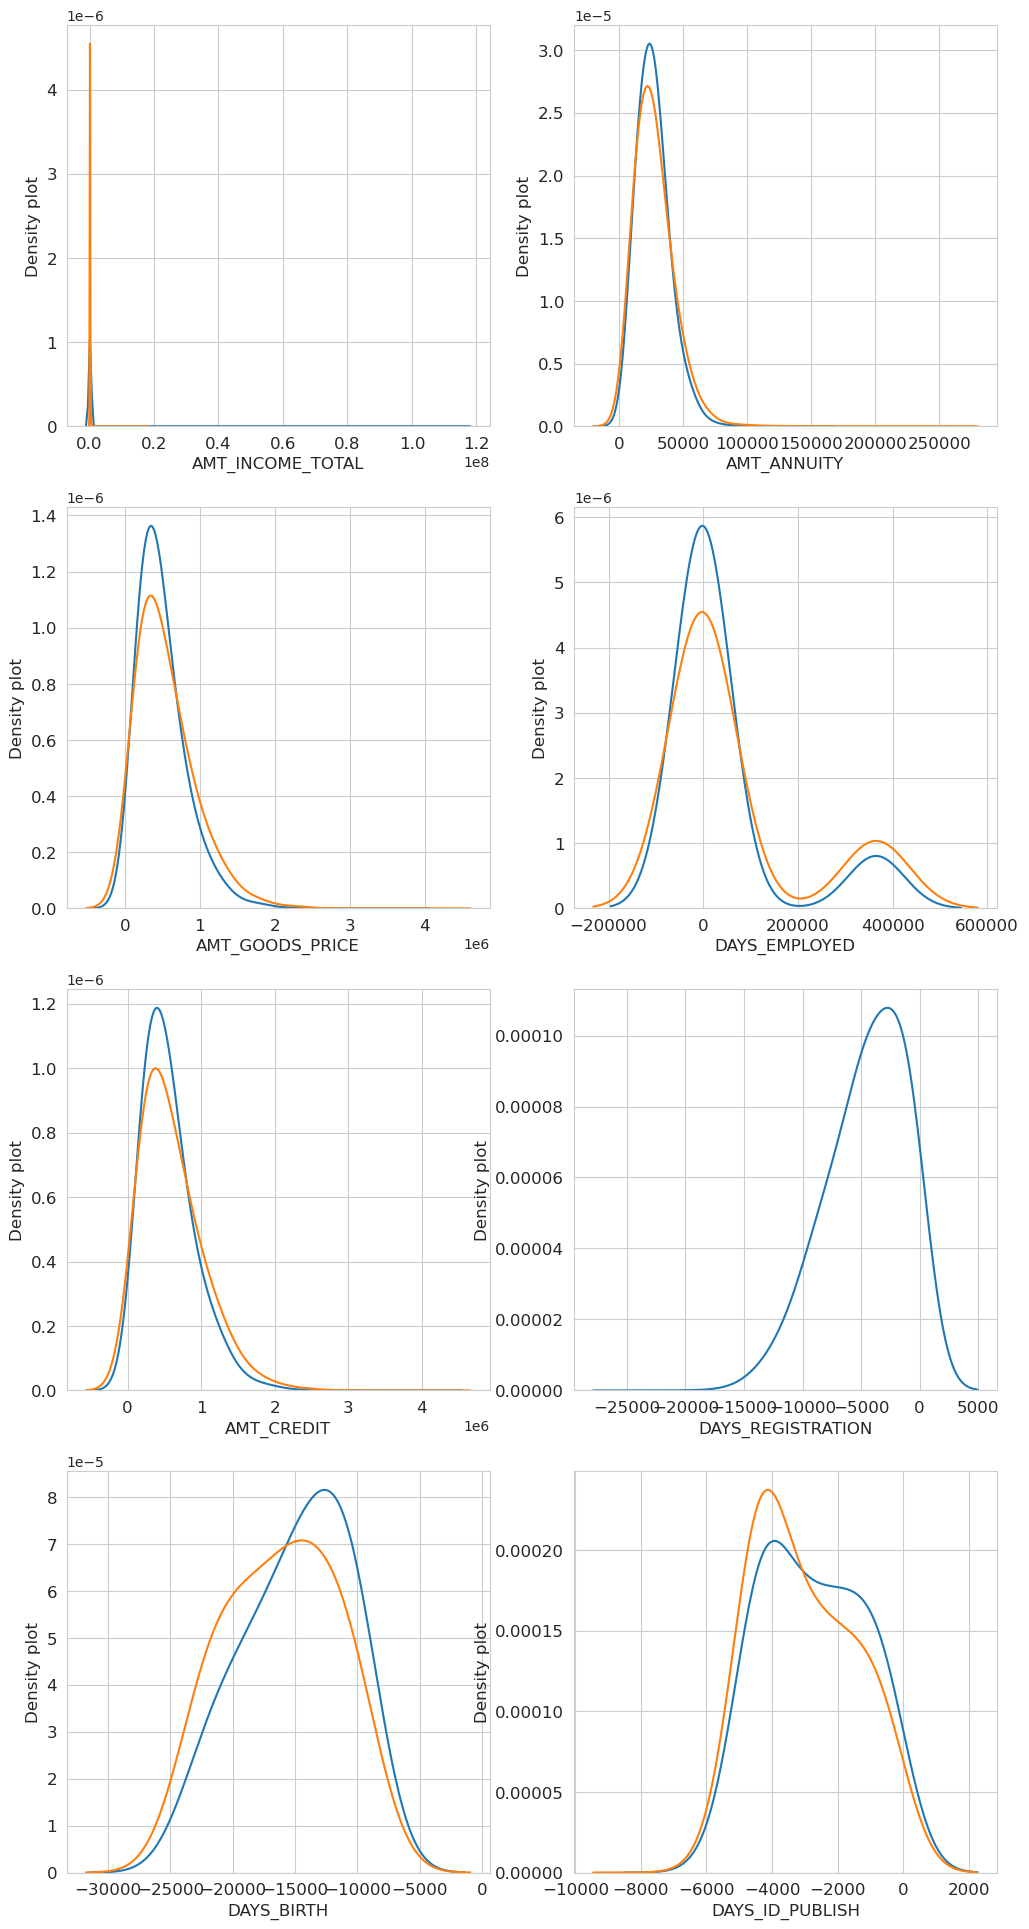

In [26]:
var = [
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_EMPLOYED",
    "AMT_CREDIT",
    "DAYS_REGISTRATION",
    "DAYS_BIRTH",
    "DAYS_ID_PUBLISH",
]
plot_distribution_comp(var, nrow=4)

## Feature engineering

In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: category(16), float16(61), float32(4), int16(2), int32(2), int8(37)
memory usage: 59.5 MB


In [28]:
es = ft.EntitySet(id = 'clients')


In [29]:
# Add identifying column
train['set'] = 'train'
test['set'] = 'test'
test["TARGET"] = np.nan

# Append the dataframes using concat
app = pd.concat([train, test], ignore_index=True)


In [30]:
# Assuming 'es' is already initialized as an EntitySet

# For dataframes with an existing unique index
es = es.add_dataframe(dataframe_name='app', dataframe=app, index='SK_ID_CURR')
es = es.add_dataframe(dataframe_name='bureau', dataframe=bureau, index='SK_ID_BUREAU')
es = es.add_dataframe(dataframe_name='previous', dataframe=previous_app, index='SK_ID_PREV')

# For dataframes that do not have a unique index, manually add an index column
bureau_balance['bureaubalance_index'] = range(1, len(bureau_balance) + 1)
pos_cash['cash_index'] = range(1, len(pos_cash) + 1)
installments['installments_index'] = range(1, len(installments) + 1)
credit_card['credit_index'] = range(1, len(credit_card) + 1)

# Now add these dataframes to the EntitySet
es = es.add_dataframe(dataframe_name='bureau_balance', dataframe=bureau_balance, index='bureaubalance_index')
es = es.add_dataframe(dataframe_name='cash', dataframe=pos_cash, index='cash_index')
es = es.add_dataframe(dataframe_name='installments', dataframe=installments, index='installments_index')
es = es.add_dataframe(dataframe_name='credit', dataframe=credit_card, index='credit_index')


In [31]:
print('Parent: app, Parent Variable: SK_ID_CURR\n\n', app.iloc[:, 111:115].head())
print('\nChild: bureau, Child Variable: SK_ID_CURR\n\n', bureau.iloc[10:30, :4].head())

Parent: app, Parent Variable: SK_ID_CURR

         FLAG_DOCUMENT_17  FLAG_DOCUMENT_18  FLAG_DOCUMENT_19  FLAG_DOCUMENT_20
100002                 0                 0                 0                 0
100003                 0                 0                 0                 0
100004                 0                 0                 0                 0
100006                 0                 0                 0                 0
100007                 0                 0                 0                 0

Child: bureau, Child Variable: SK_ID_CURR

          SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY
5714472      162297       5714472        Active      currency 1
5714473      162297       5714473        Closed      currency 1
5714474      162297       5714474        Active      currency 1
5714475      402440       5714475        Active      currency 1
5714482      238881       5714482        Closed      currency 1


In [32]:
# Assuming `add_relationships` method is available and correct for your version

# Define relationships based on logical connections (foreign keys) between the dataframes
relationships = [
    ('app', 'SK_ID_CURR', 'bureau', 'SK_ID_CURR'),
    ('bureau', 'SK_ID_BUREAU', 'bureau_balance', 'SK_ID_BUREAU'),
    ('app', 'SK_ID_CURR', 'previous', 'SK_ID_CURR'),
    ('previous', 'SK_ID_PREV', 'cash', 'SK_ID_PREV'),
    ('previous', 'SK_ID_PREV', 'installments', 'SK_ID_PREV'),
    ('previous', 'SK_ID_PREV', 'credit', 'SK_ID_PREV')
]

# Add relationships to the EntitySet
for parent_df, parent_col, child_df, child_col in relationships:
    es.add_relationship(parent_dataframe_name=parent_df, parent_column_name=parent_col,
                        child_dataframe_name=child_df, child_column_name=child_col)


Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 123]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    cash [Rows: 10001358, Columns: 9]
    installments [Rows: 13605401, Columns: 9]
    credit [Rows: 3840312, Columns: 24]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR

Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 123]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    cash [Rows: 10001358, Columns: 9]
    installments [Rows: 13605401, Columns: 9]
    credit [Rows: 3840312, Columns: 24]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU

Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 123]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    cash [Rows: 10001358, Columns: 9]
    installments [Rows: 13605401, Columns: 9]
    credit [Rows: 3840312, Columns: 24]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
    previous.SK_ID_CURR -> app.SK_ID_CURR

Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 123]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    cash [Rows: 10001358, Columns: 9]
    installments [Rows: 13605401, Columns: 9]
    credit [Rows: 3840312, Columns: 24]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
    previous.SK_ID_CURR -> app.SK_ID_CURR
    cash.SK_ID_PREV -> previous.SK_ID_PREV

Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 123]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    cash [Rows: 10001358, Columns: 9]
    installments [Rows: 13605401, Columns: 9]
    credit [Rows: 3840312, Columns: 24]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
    previous.SK_ID_CURR -> app.SK_ID_CURR
    cash.SK_ID_PREV -> previous.SK_ID_PREV
    installments.SK_ID_PREV -> previous.SK_ID_PREV

Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 123]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    cash [Rows: 10001358, Columns: 9]
    installments [Rows: 13605401, Columns: 9]
    credit [Rows: 3840312, Columns: 24]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
    previous.SK_ID_CURR -> app.SK_ID_CURR
    cash.SK_ID_PREV -> previous.SK_ID_PREV
    installments.SK_ID_PREV -> previous.SK_ID_PREV
    credit.SK_ID_PREV -> previous.SK_ID_PREV

## Feature Primitives


In [33]:
primitives = ft.list_primitives()
pd.options.display.max_colwidth = 100
primitives[primitives['type'] == 'aggregation'].head(10)

,name,type,dask_compatible,spark_compatible,description,valid_inputs,return_type
0,time_since_first,aggregation,False,False,Calculates the time elapsed since the first datetime (in seconds).,<ColumnSchema (Logical Type = Datetime) (Semantic Tags = ['time_index'])>,<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
1,n_most_common,aggregation,False,False,Determines the `n` most common elements.,<ColumnSchema (Semantic Tags = ['category'])>,None
2,num_consecutive_less_mean,aggregation,False,False,Determines the length of the longest subsequence below the mean.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>
3,percent_true,aggregation,True,False,Determines the percent of `True` values.,"<ColumnSchema (Logical Type = Boolean)>, <ColumnSchema (Logical Type = BooleanNullable)>",<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
4,max,aggregation,True,True,"Calculates the highest value, ignoring `NaN` values.",<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
5,kurtosis,aggregation,False,False,Calculates the kurtosis for a list of numbers,"<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>, <ColumnSchema (Logical Typ...",<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
6,num_false_since_last_true,aggregation,False,False,Calculates the number of 'False' values since the last `True` value. Description: From a series ...,<ColumnSchema (Logical Type = Boolean)>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>
7,n_unique_months,aggregation,False,False,Determines the number of unique months.,<ColumnSchema (Logical Type = Datetime)>,<ColumnSchema (Logical Type = Integer) (Semantic Tags = ['numeric'])>
8,count,aggregation,True,True,"Determines the total number of values, excluding `NaN`.",<ColumnSchema (Semantic Tags = ['index'])>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>
9,num_unique,aggregation,True,True,"Determines the number of distinct values, ignoring `NaN` values.",<ColumnSchema (Semantic Tags = ['category'])>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>


In [34]:
primitives[primitives['type'] == 'transform'].head(10)

,name,type,dask_compatible,spark_compatible,description,valid_inputs,return_type
65,multiply_numeric,transform,True,True,Performs element-wise multiplication of two lists.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
66,divide_by_feature,transform,True,True,Divides a scalar by each value in the list.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
67,rolling_std,transform,False,False,Calculates the standard deviation of entries over a given window.,"<ColumnSchema (Logical Type = Datetime) (Semantic Tags = ['time_index'])>, <ColumnSchema (Semant...",<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
68,is_quarter_start,transform,True,True,Determines the is_quarter_start attribute of a datetime column.,<ColumnSchema (Logical Type = Datetime)>,<ColumnSchema (Logical Type = BooleanNullable)>
69,number_of_unique_words,transform,False,False,Determines the number of unique words in a string.,<ColumnSchema (Logical Type = NaturalLanguage)>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>
70,mean_characters_per_word,transform,False,False,Determines the mean number of characters per word.,<ColumnSchema (Logical Type = NaturalLanguage)>,<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
71,cumulative_time_since_last_true,transform,False,False,Determines the time (in seconds) since the last boolean was `True` given a datetime index column...,"<ColumnSchema (Logical Type = Datetime) (Semantic Tags = ['time_index'])>, <ColumnSchema (Logica...",<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
72,expanding_std,transform,False,False,Computes the expanding standard deviation for events over a given window.,"<ColumnSchema (Logical Type = Datetime) (Semantic Tags = ['time_index'])>, <ColumnSchema (Semant...",<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
73,percentile,transform,False,False,Determines the percentile rank for each value in a list.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
74,not_equal_scalar,transform,True,True,Determines if values in a list are not equal to a given scalar.,<ColumnSchema>,<ColumnSchema (Logical Type = BooleanNullable)>


## DFS with Default Primitives

In [35]:
default_agg_primitives = [
    "sum", "std", "max", "skew", "min", "mean", "count",
    "percent_true", "num_unique", "mode"
]
default_trans_primitives = [
    "day", "year", "month", "weekday", "haversine"
]

# DFS with the adjusted list of primitives
feature_names = ft.dfs(entityset=es, 
                       target_dataframe_name='app',
                       agg_primitives=default_agg_primitives,
                       trans_primitives=default_trans_primitives,
                       max_depth=2, 
                       features_only=True)

print(f'{len(feature_names)} Total Features')



2213 Total Features


In [36]:
feature_names[-20:]

[<Feature: STD(credit.previous.SELLERPLACE_AREA)>,
 <Feature: SUM(credit.previous.AMT_ANNUITY)>,
 <Feature: SUM(credit.previous.AMT_APPLICATION)>,
 <Feature: SUM(credit.previous.AMT_CREDIT)>,
 <Feature: SUM(credit.previous.AMT_DOWN_PAYMENT)>,
 <Feature: SUM(credit.previous.AMT_GOODS_PRICE)>,
 <Feature: SUM(credit.previous.CNT_PAYMENT)>,
 <Feature: SUM(credit.previous.DAYS_DECISION)>,
 <Feature: SUM(credit.previous.DAYS_FIRST_DRAWING)>,
 <Feature: SUM(credit.previous.DAYS_FIRST_DUE)>,
 <Feature: SUM(credit.previous.DAYS_LAST_DUE)>,
 <Feature: SUM(credit.previous.DAYS_LAST_DUE_1ST_VERSION)>,
 <Feature: SUM(credit.previous.DAYS_TERMINATION)>,
 <Feature: SUM(credit.previous.HOUR_APPR_PROCESS_START)>,
 <Feature: SUM(credit.previous.NFLAG_INSURED_ON_APPROVAL)>,
 <Feature: SUM(credit.previous.NFLAG_LAST_APPL_IN_DAY)>,
 <Feature: SUM(credit.previous.RATE_DOWN_PAYMENT)>,
 <Feature: SUM(credit.previous.RATE_INTEREST_PRIMARY)>,
 <Feature: SUM(credit.previous.RATE_INTEREST_PRIVILEGED)>,
 <Feature:

In [37]:
# Specify the aggregation primitives
feature_matrix_spec, feature_names_spec = ft.dfs(entityset = es, target_dataframe_name = 'app',  
                                                 agg_primitives = ['sum', 'count', 'min', 'max', 'mean', 'mode'], 
                                                 max_depth = 2, features_only = False, verbose = True)

Built 1211 features
Elapsed: 00:57 | Progress:   9%|▉         

: 

In [ ]:
pd.options.display.max_columns = 1000
feature_matrix_spec.head(10)